# Proyecto: Predicción de Churn en Distribución de Streaming

## Contexto del Negocio
Este proyecto se desarrolla dentro de un modelo de emprendimiento enfocado en la **distribución y reventa de perfiles de plataformas de streaming** (MAX, Netflix, Crunchyroll, etc.).

### Objetivos
- **Variable Target (objetivo):** `churn` (0 = cliente activo, 1 = cliente que abandonó)
- **Técnica básica:** Regresión Logística
- **Técnica avanzada:** Random Forest





In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')
print('Librerías importadas correctamente')

Librerías importadas correctamente


# Carga del Dataset

In [ ]:
df = pd.read_csv('dataset_streaming_limpio.csv')
print(f'Dimensiones del dataset: {df.shape}')
print(f'\nColumnas: {list(df.columns)}')
df.head(10)

Dimensiones del dataset: (245, 10)

Columnas: ['id_cliente', 'plataforma', 'duracion_plan', 'duracion_meses', 'tipo_plan', 'mes_inicio', 'tiene_fecha_inicio', 'ultima_conexion', 'horas_consumidas', 'churn']


,id_cliente,plataforma,duracion_plan,duracion_meses,tipo_plan,mes_inicio,tiene_fecha_inicio,ultima_conexion,horas_consumidas,churn
0,CLIENTE_0001,MAX,1 año,12,largo,11,0,7,163.3,0
1,CLIENTE_0002,MAX,1 año,12,largo,5,1,122,35.6,1
2,CLIENTE_0003,MAX,6 meses,6,largo,9,1,44,9.4,1
3,CLIENTE_0004,MAX,1 mes,1,corto,2,1,136,1.4,1
4,CLIENTE_0005,MAX,1 año,12,largo,8,1,8,94.0,0
5,CLIENTE_0006,MAX,3 meses,3,medio,4,1,29,10.6,0
6,CLIENTE_0007,Crunchyroll,1 año,12,largo,5,1,50,78.2,1
7,CLIENTE_0008,Crunchyroll,1 año,12,largo,5,1,132,79.6,1
8,CLIENTE_0009,Crunchyroll,1 año,12,largo,5,1,151,82.6,1
9,CLIENTE_0010,Crunchyroll,1 año,12,largo,11,1,19,166.1,0


In [ ]:
print('=== INFORMACIÓN DEL DATASET ===')
print(df.info())


=== INFORMACIÓN DEL DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_cliente          245 non-null    object 
 1   plataforma          245 non-null    object 
 2   duracion_plan       245 non-null    object 
 3   duracion_meses      245 non-null    int64  
 4   tipo_plan           245 non-null    object 
 5   mes_inicio          245 non-null    int64  
 6   tiene_fecha_inicio  245 non-null    int64  
 7   ultima_conexion     245 non-null    int64  
 8   horas_consumidas    245 non-null    float64
 9   churn               245 non-null    int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 19.3+ KB
None


In [ ]:
print('=== VALORES NULOS ===')
print(df.isnull().sum())
print(f'\n=== DISTRIBUCIÓN DEL TARGET (churn) ===')
print(df['churn'].value_counts())
print(f'\nTasa de Churn: {df["churn"].mean():.2%}')

=== VALORES NULOS ===
id_cliente            0
plataforma            0
duracion_plan         0
duracion_meses        0
tipo_plan             0
mes_inicio            0
tiene_fecha_inicio    0
ultima_conexion       0
horas_consumidas      0
churn                 0
dtype: int64

=== DISTRIBUCIÓN DEL TARGET (churn) ===
churn
0    167
1     78
Name: count, dtype: int64

Tasa de Churn: 31.84%


## Análisis Exploratorio de Datos

### Distribución de la Variable Target

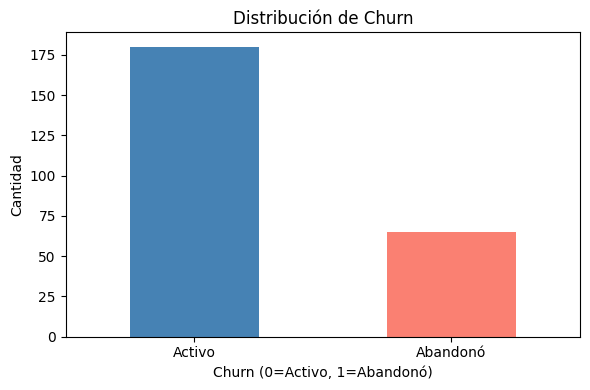

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
df['churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], ax=ax)
ax.set_title('Distribución de Churn')
ax.set_xlabel('Churn (0=Activo, 1=Abandonó)')
ax.set_ylabel('Cantidad')
ax.set_xticklabels(['Activo', 'Abandonó'], rotation=0)
plt.tight_layout()
plt.show()

### Distribución por Plataforma

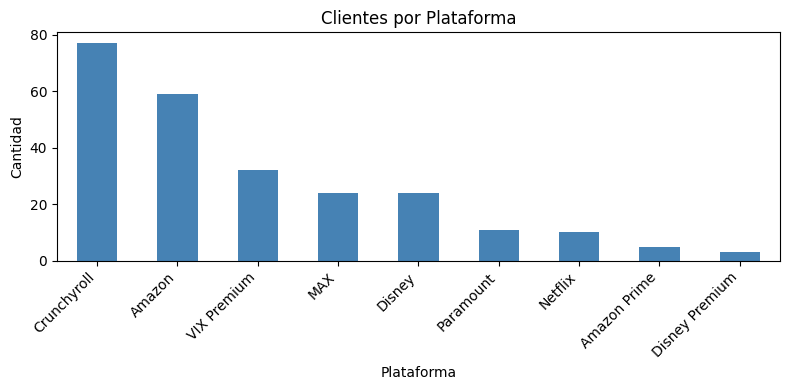

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
df['plataforma'].value_counts().plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Clientes por Plataforma')
ax.set_xlabel('Plataforma')
ax.set_ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Churn por Duración del Plan

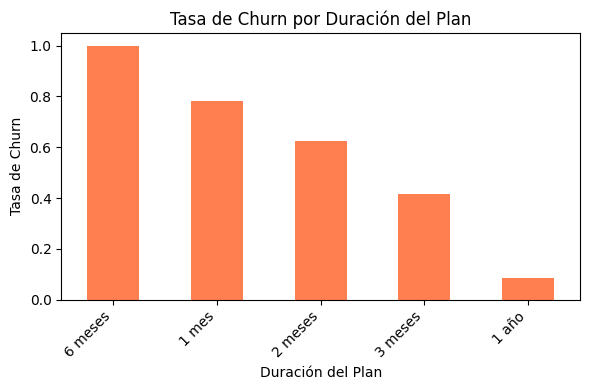

In [ ]:
churn_por_duracion = df.groupby('duracion_plan')['churn'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
churn_por_duracion.plot(kind='bar', color='coral', ax=ax)
ax.set_title('Tasa de Churn por Duración del Plan')
ax.set_xlabel('Duración del Plan')
ax.set_ylabel('Tasa de Churn')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Churn por Plataforma

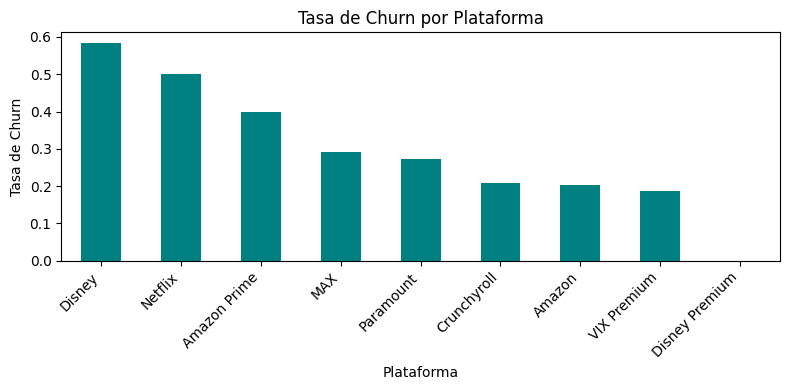

In [ ]:
churn_por_plat = df.groupby('plataforma')['churn'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
churn_por_plat.plot(kind='bar', color='teal', ax=ax)
ax.set_title('Tasa de Churn por Plataforma')
ax.set_xlabel('Plataforma')
ax.set_ylabel('Tasa de Churn')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Preprocesamiento de Datos

###  Codificación de Variables Categóricas

In [ ]:
# Codificar variables categóricas
le_plataforma = LabelEncoder()
le_tipo_plan = LabelEncoder()

df['plataforma_encoded'] = le_plataforma.fit_transform(df['plataforma'])
df['tipo_plan_encoded'] = le_tipo_plan.fit_transform(df['tipo_plan'])

print('Mapeo de Plataforma:')
for i, clase in enumerate(le_plataforma.classes_):
    print(f'  {clase} -> {i}')

print('\nMapeo de Tipo de Plan:')
for i, clase in enumerate(le_tipo_plan.classes_):
    print(f'  {clase} -> {i}')

Mapeo de Plataforma:
  Amazon -> 0
  Amazon Prime -> 1
  Crunchyroll -> 2
  Disney -> 3
  Disney Premium -> 4
  MAX -> 5
  Netflix -> 6
  Paramount -> 7
  VIX Premium -> 8

Mapeo de Tipo de Plan:
  corto -> 0
  largo -> 1
  medio -> 2


### Variables Predictoras

In [ ]:
# Variables predictoras (features)
features = ['duracion_meses', 'plataforma_encoded', 'tipo_plan_encoded',
             'mes_inicio', 'tiene_fecha_inicio','ultima_conexion','horas_consumidas']

X = df[features].copy()
y = df['churn'].copy()

print(f'Features seleccionadas: {features}')
print(f'Shape de X: {X.shape}')
print(f'Shape de y: {y.shape}')
print(f'\nPrimeras filas de X:')
X.head()

Features seleccionadas: ['duracion_meses', 'plataforma_encoded', 'tipo_plan_encoded', 'mes_inicio', 'tiene_fecha_inicio', 'ultima_conexion', 'horas_consumidas']
Shape de X: (245, 7)
Shape de y: (245,)

Primeras filas de X:


,duracion_meses,plataforma_encoded,tipo_plan_encoded,mes_inicio,tiene_fecha_inicio,ultima_conexion,horas_consumidas
0,12,5,1,11,0,7,163.3
1,12,5,1,5,1,122,35.6
2,6,5,1,9,1,44,9.4
3,1,5,0,2,1,136,1.4
4,12,5,1,8,1,8,94.0


### División Train/Test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]} muestras')
print(f'Conjunto de prueba: {X_test.shape[0]} muestras')
print(f'\nDistribución de churn en entrenamiento:')
print(y_train.value_counts())
print(f'\nDistribución de churn en prueba:')
print(y_test.value_counts())

Conjunto de entrenamiento: 171 muestras
Conjunto de prueba: 74 muestras

Distribución de churn en entrenamiento:
churn
0    117
1     54
Name: count, dtype: int64

Distribución de churn en prueba:
churn
0    50
1    24
Name: count, dtype: int64


### Escalamiento de Features

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Datos escalados correctamente')
print(f'Media de X_train_scaled: {X_train_scaled.mean(axis=0).round(4)}')
print(f'Std de X_train_scaled: {X_train_scaled.std(axis=0).round(4)}')

Datos escalados correctamente
Media de X_train_scaled: [-0. -0. -0.  0.  0. -0.  0.]
Std de X_train_scaled: [1. 1. 1. 1. 1. 1. 1.]


##Regresión Logística

In [ ]:

lr = LogisticRegression(penalty='l2', C=1.0, random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# Predicciones
y_pred_lr = lr.predict(X_test_scaled)
y_probs_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('Primeras 10 predicciones vs valores reales:')
for i in range(min(10, len(y_test))):
    real = y_test.iloc[i]
    pred = y_pred_lr[i]
    prob = y_probs_lr[i]
    print(f'  Real: {real} | Predicción: {pred} | P(churn): {prob:.4f}')

Primeras 10 predicciones vs valores reales:
  Real: 1 | Predicción: 1 | P(churn): 0.9998
  Real: 0 | Predicción: 0 | P(churn): 0.0042
  Real: 0 | Predicción: 0 | P(churn): 0.0010
  Real: 0 | Predicción: 0 | P(churn): 0.0108
  Real: 0 | Predicción: 0 | P(churn): 0.0030
  Real: 1 | Predicción: 1 | P(churn): 0.8560
  Real: 0 | Predicción: 0 | P(churn): 0.0423
  Real: 1 | Predicción: 1 | P(churn): 0.9710
  Real: 1 | Predicción: 1 | P(churn): 0.9640
  Real: 1 | Predicción: 1 | P(churn): 0.9896


In [ ]:
# Métricas
print('=== REPORTE DE CLASIFICACIÓN - Regresión Logística ===')
print(classification_report(y_test, y_pred_lr, target_names=['Activo', 'Churn']))

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f'Accuracy: {acc_lr:.4f}')

=== REPORTE DE CLASIFICACIÓN - Regresión Logística ===
              precision    recall  f1-score   support

      Activo       0.94      0.98      0.96        50
       Churn       0.95      0.88      0.91        24

    accuracy                           0.95        74
   macro avg       0.95      0.93      0.94        74
weighted avg       0.95      0.95      0.95        74

Accuracy: 0.9459


In [ ]:
from sklearn.model_selection import GridSearchCV

lr_base = LogisticRegression(penalty='l2', class_weight='balanced', random_state=42, max_iter=1000)


param_grid = {
    'C': [0.1, 0.5, 1, 5, 10, 50]
}

grid_search = GridSearchCV(lr_base, param_grid, cv=5, scoring='f1_weighted')
grid_search.fit(X_train_scaled, y_train)

lr_best = grid_search.best_estimator_

print(f'Mejor valor de C encontrado: {grid_search.best_params_["C"]}')
print(f'Mejor puntuación F1-Weighted (CV): {grid_search.best_score_:.4f}')

# Predicciones con el mejor modelo
y_pred_lr = lr_best.predict(X_test_scaled)
y_probs_lr = lr_best.predict_proba(X_test_scaled)[:, 1]

# Métricas
print('\n=== REPORTE DE CLASIFICACIÓN - Regresión Logística (Optimizado y Balanceado) ===')
print(classification_report(y_test, y_pred_lr, target_names=['Activo', 'Churn']))

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f'Accuracy: {acc_lr:.4f}')

print('\nPrimeras 10 predicciones con el modelo corregido:')
for i in range(min(10, len(y_test))):
    real = y_test.iloc[i]
    pred = y_pred_lr[i]
    prob = y_probs_lr[i]
    print(f'  Real: {real} | Predicción: {pred} | P(churn): {prob:.4f}')

Mejor valor de C encontrado: 50
Mejor puntuación F1-Weighted (CV): 0.9765

=== REPORTE DE CLASIFICACIÓN - Regresión Logística (Optimizado y Balanceado) ===
              precision    recall  f1-score   support

      Activo       0.96      1.00      0.98        50
       Churn       1.00      0.92      0.96        24

    accuracy                           0.97        74
   macro avg       0.98      0.96      0.97        74
weighted avg       0.97      0.97      0.97        74

Accuracy: 0.9730

Primeras 10 predicciones con el modelo corregido:
  Real: 1 | Predicción: 1 | P(churn): 1.0000
  Real: 0 | Predicción: 0 | P(churn): 0.0000
  Real: 0 | Predicción: 0 | P(churn): 0.0000
  Real: 0 | Predicción: 0 | P(churn): 0.0000
  Real: 0 | Predicción: 0 | P(churn): 0.0000
  Real: 1 | Predicción: 1 | P(churn): 1.0000
  Real: 0 | Predicción: 0 | P(churn): 0.0007
  Real: 1 | Predicción: 1 | P(churn): 1.0000
  Real: 1 | Predicción: 1 | P(churn): 1.0000
  Real: 1 | Predicción: 1 | P(churn): 1.0000

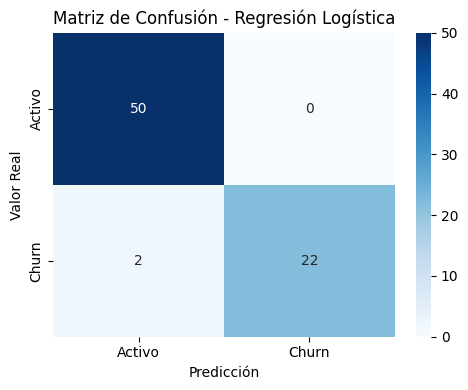

In [ ]:
# Matriz de Confusión
cm_lr = confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Activo', 'Churn'], yticklabels=['Activo', 'Churn'])
ax.set_title('Matriz de Confusión - Regresión Logística')
ax.set_xlabel('Predicción')
ax.set_ylabel('Valor Real')
plt.tight_layout()
plt.show()

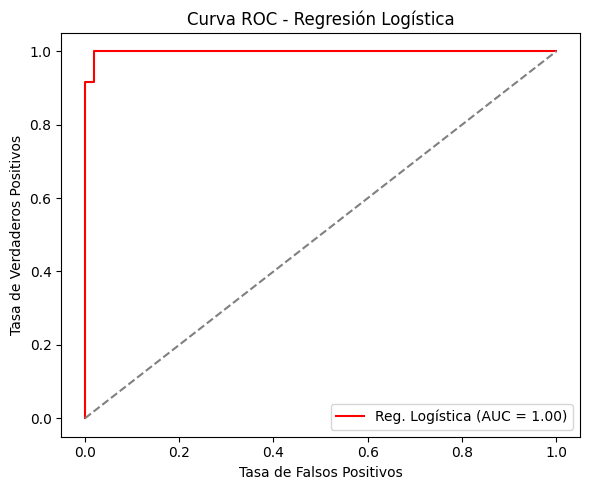

ROC-AUC Score: 0.9983


In [ ]:
# Curva ROC
auc_lr = roc_auc_score(y_test, y_probs_lr)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_probs_lr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr_lr, tpr_lr, color='red', label=f'Reg. Logística (AUC = {auc_lr:.2f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curva ROC - Regresión Logística')
ax.legend()
plt.tight_layout()
plt.show()
print(f'ROC-AUC Score: {auc_lr:.4f}')

## Random Forest

## Random Forest

Un **Random Forest** entrena varios árboles de decisión. Cada árbol se entrena con una muestra aleatoria de los datos y con subconjuntos aleatorios de variables. Finalmente, el bosque decide por **votación mayoritaria**. Esto produce modelos más robustos que un solo árbol de decisión.


1. Entrenamiento del modelo
2. Evaluación con tabla train/test (accuracy, precision, recall, F1)
3. Reporte de clasificación completo
4. Matriz de confusión con `ConfusionMatrixDisplay`
5. Importancia de variables
6. Exploración interna: votación de los árboles para un caso
7. Estadísticas de profundidad y hojas del bosque
8. Comparación RF vs. mejor árbol del bosque vs. árbol independiente (GridSearchCV)
9. Experimentación con hiperparámetros

In [ ]:
RANDOM_STATE = 42

# Entrenamiento del Random Forest
# n_estimators=200 árboles, class_weight='balanced' para manejar desbalance de clases
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train_scaled, y_train)

y_train_pred = rf.predict(X_train_scaled)
y_test_pred  = rf.predict(X_test_scaled)

print('Modelo Random Forest entrenado exitosamente')
print(f'Número de árboles: {rf.n_estimators}')

Modelo Random Forest entrenado exitosamente
Número de árboles: 200


### Evaluación del Modelo: Train vs. Test

Comparamos el rendimiento en entrenamiento y en prueba para detectar posible **sobreajuste**: si el accuracy de train es mucho mayor que el de test, el modelo memorizó los datos en lugar de aprender patrones generalizables.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluar_modelo(nombre, y_real, y_pred):
    """Calcula métricas principales para un modelo de clasificación binaria."""
    return pd.Series({
        'modelo': nombre,
        'accuracy':  accuracy_score(y_real, y_pred),
        'precision': precision_score(y_real, y_pred, zero_division=0),
        'recall':    recall_score(y_real, y_pred, zero_division=0),
        'f1_score':  f1_score(y_real, y_pred, zero_division=0)
    })

resultados_rf = pd.DataFrame([
    evaluar_modelo('Random Forest - train', y_train, y_train_pred),
    evaluar_modelo('Random Forest - test',  y_test,  y_test_pred)
])

# Mostrar resultados
print('Métricas de rendimiento:')
display(resultados_rf.set_index('modelo').round(3))

print('\nReporte de clasificación en el conjunto de prueba:')
print(classification_report(y_test, y_test_pred, target_names=['Activo (0)', 'Churn (1)']))

Métricas de rendimiento:


,accuracy,precision,recall,f1_score
modelo,,,,
Random Forest - train,1.000,1.0,1.000,1.000
Random Forest - test,0.973,1.0,0.917,0.957



Reporte de clasificación en el conjunto de prueba:
              precision    recall  f1-score   support

  Activo (0)       0.96      1.00      0.98        50
   Churn (1)       1.00      0.92      0.96        24

    accuracy                           0.97        74
   macro avg       0.98      0.96      0.97        74
weighted avg       0.97      0.97      0.97        74



### Matriz de Confusión

La matriz de confusión muestra en qué casos acierta y en cuáles se equivoca el modelo:
- **Verdaderos negativos (TN):** clientes activos correctamente clasificados
- **Falsos positivos (FP):** clientes activos clasificados como churn
- **Falsos negativos (FN):** clientes churn que el modelo no detectó (estos nos importan)
- **Verdaderos positivos (TP):** clientes churn correctamente detectados

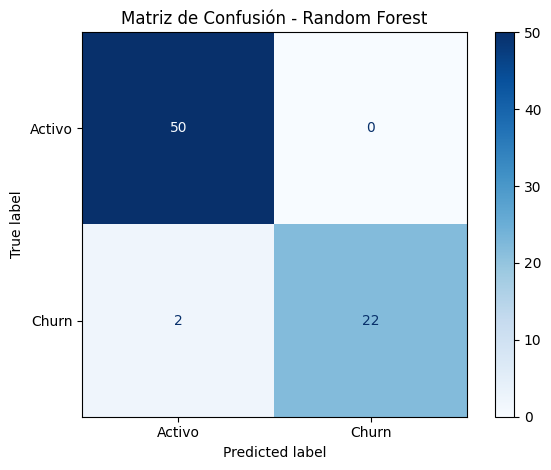

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=['Activo', 'Churn']
)

disp.plot(cmap='Blues', values_format='d')
plt.title('Matriz de Confusión - Random Forest')
plt.tight_layout()
plt.show()

Importancia de variables:


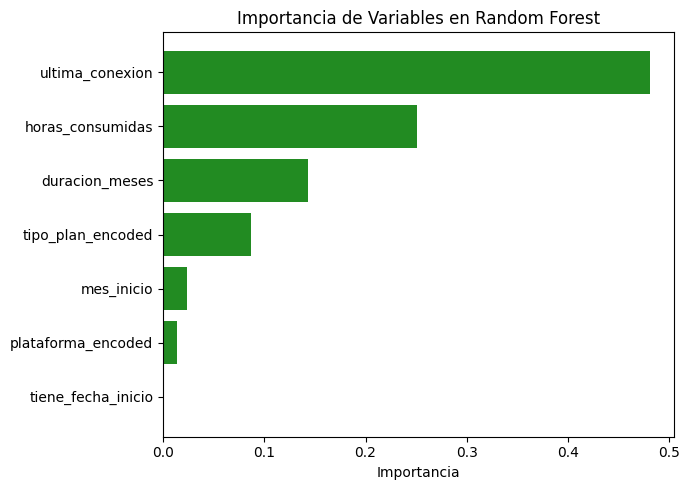

In [ ]:
importancias = pd.DataFrame({
    'variable':    features,
    'importancia': rf.feature_importances_
}).sort_values(by='importancia', ascending=False)

print('Importancia de variables:')
importancias.round(4)
plt.figure(figsize=(7, 5))
plt.barh(importancias['variable'], importancias['importancia'], color='forestgreen')
plt.gca().invert_yaxis()
plt.xlabel('Importancia')
plt.title('Importancia de Variables en Random Forest')
plt.tight_layout()
plt.show()

###  ¿Cómo Votan los Árboles?

Cada árbol produce una predicción individual. El Random Forest toma la **clase más votada**. Analicemos un cliente específico del conjunto de prueba para ver cómo se distribuyen los votos.

In [ ]:
print(f'Número de árboles en el bosque: {len(rf.estimators_)}')
print(type(rf.estimators_[0]))

Número de árboles en el bosque: 200
<class 'sklearn.tree._classes.DecisionTreeClassifier'>


In [ ]:
# Analizar el cliente en el índice 5 del conjunto de prueba
idx0 = 5

new_x       = X_test.iloc[[idx0]]          # conservar formato DataFrame
new_x_sc    = X_test_scaled[idx0:idx0+1]   # versión escalada
real_label  = y_test.iloc[idx0]
rf_label    = rf.predict(new_x_sc)[0]

print(f'Índice analizado dentro de X_test: {idx0}')
print(f'Etiqueta real:                     {real_label}  (0=Activo, 1=Churn)')
print(f'Predicción del Random Forest:      {rf_label}')

# Predicción de cada árbol individual
predicciones_arboles = np.array([
    arbol.predict(new_x_sc)[0] for arbol in rf.estimators_
])

votos_0 = int(np.sum(predicciones_arboles == 0))
votos_1 = int(np.sum(predicciones_arboles == 1))

print(f'\nVotos para Activo (0): {votos_0}')
print(f'Votos para Churn  (1): {votos_1}')
print(f'Primeras 20 predicciones individuales: {predicciones_arboles[:20]}')

Índice analizado dentro de X_test: 5
Etiqueta real:                     1  (0=Activo, 1=Churn)
Predicción del Random Forest:      1

Votos para Activo (0): 24
Votos para Churn  (1): 176
Primeras 20 predicciones individuales: [1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1.]


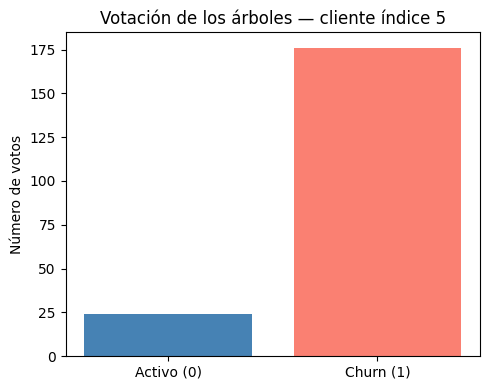

In [ ]:
plt.figure(figsize=(5, 4))
plt.bar(['Activo (0)', 'Churn (1)'], [votos_0, votos_1], color=['steelblue', 'salmon'])
plt.ylabel('Número de votos')
plt.title(f'Votación de los árboles — cliente índice {idx0}')
plt.tight_layout()
plt.show()

### COMPARACION DE MODELOS


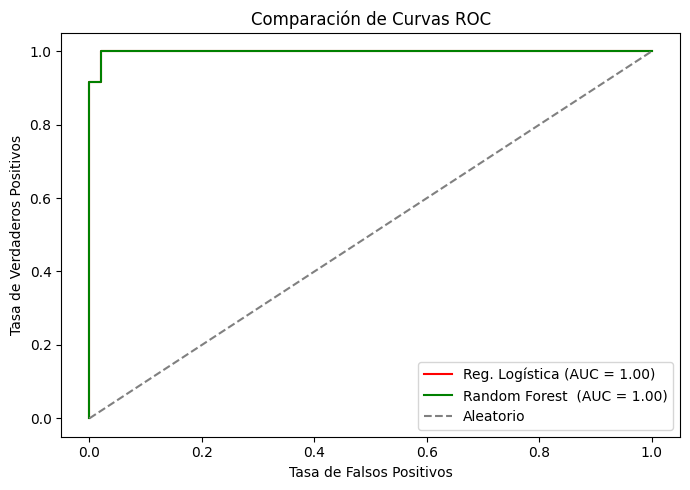

In [ ]:
# Curvas ROC comparativas: Regresión Logística vs. Random Forest
auc_rf  = roc_auc_score(y_test, rf.predict_proba(X_test_scaled)[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test_scaled)[:, 1])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, color='red',   label=f'Reg. Logística (AUC = {auc_lr:.2f})')
ax.plot(fpr_rf, tpr_rf, color='green', label=f'Random Forest  (AUC = {auc_rf:.2f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Comparación de Curvas ROC')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:

acc_rf  = accuracy_score(y_test, y_test_pred)

comparacion_final = pd.DataFrame({
    'Modelo':   ['Regresión Logística', 'Random Forest'],
    'Accuracy': [acc_lr, acc_rf],
    'ROC-AUC':  [auc_lr, auc_rf]
})
print('=== COMPARACIÓN FINAL DE MODELOS ===')
print(comparacion_final.to_string(index=False))

mejor = 'Regresión Logística' if auc_lr > auc_rf else 'Random Forest'
print(f'\nMejor modelo según ROC-AUC: {mejor}')

=== COMPARACIÓN FINAL DE MODELOS ===
             Modelo  Accuracy  ROC-AUC
Regresión Logística  0.972973 0.998333
      Random Forest  0.972973 0.998333

Mejor modelo según ROC-AUC: Random Forest


In [65]:

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

features_svm = [
    'duracion_meses', 'mes_inicio', 'tiene_fecha_inicio',
    'ultima_conexion', 'horas_consumidas'
]

X_svm = df[features_svm]
y_svm = df['churn']

# División consistente
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_svm, y_svm, test_size=0.3, random_state=42, stratify=y_svm
)

# Escalamos el set completo
scaler_svm = StandardScaler()
X_train_scaled = scaler_svm.fit_transform(X_train_s)
X_test_scaled = scaler_svm.transform(X_test_s)


X_train_2d = X_train_scaled[:, [3, 4]]
X_test_2d = X_test_scaled[:, [3, 4]]

print("Dataset preparado. Las visualizaciones 2D ahora usarán los ejes de comportamiento (Conexión vs Horas).")

Dataset preparado. Las visualizaciones 2D ahora usarán los ejes de comportamiento (Conexión vs Horas).


In [70]:
def make_meshgrid(x, y, h=0.05):
    """Crea una malla de puntos para delimitar las regiones de decisión."""
    x_min, x_max = x.min() - 0.5, x.max() + 0.5
    y_min, y_max = y.min() - 0.5, y.max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    """Grafica los contornos de las regiones de predicción del modelo."""
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

def plot_decision_regions(model, X_train, y_train, X_test=None, y_test=None, title="Frontera de decisión"):
    """Grafica la frontera de decisión comparando el set de entrenamiento y prueba."""
    # Usamos índices 0 y 1 porque X_train_2d solo tiene 2 columnas
    xx, yy = make_meshgrid(X_train[:, 0], X_train[:, 1])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

    # Panel de Entrenamiento
    plot_contours(ax1, model, xx, yy, cmap=plt.cm.coolwarm, alpha=0.25)
    scatter1 = ax1.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.coolwarm, s=35, edgecolors="k")
    ax1.set_title("Set de Entrenamiento")
    ax1.set_xlabel("Última Conexión (Escalado)")
    ax1.set_ylabel("Horas Consumidas (Escalado)")
    ax1.legend(*scatter1.legend_elements(), title="Churn")

    # Panel de Prueba
    if X_test is not None:
        plot_contours(ax2, model, xx, yy, cmap=plt.cm.coolwarm, alpha=0.25)
        scatter2 = ax2.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm, s=35, edgecolors="k")
        ax2.set_title("Set de Prueba")
        ax2.set_xlabel("Última Conexión (Escalado)")
        ax2.set_ylabel("Horas Consumidas (Escalado)")
        ax2.legend(*scatter2.legend_elements(), title="Churn")

    fig.suptitle(title, fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

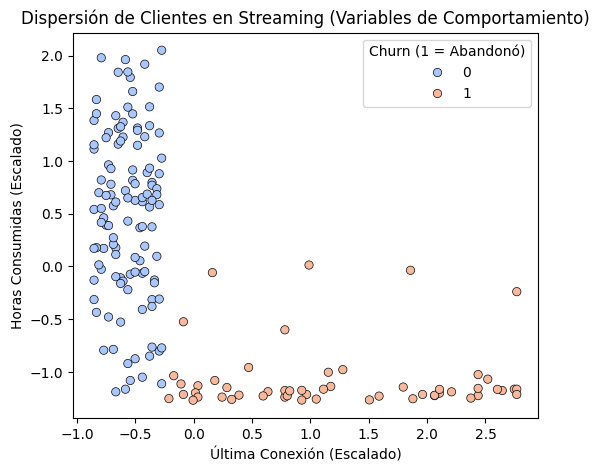

In [77]:
# Graficamos los datos reales en el espacio 2D antes de trazar fronteras
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_train_2d[:, 0], y=X_train_2d[:, 1], hue=y_train_s, palette="coolwarm", edgecolor="k")
plt.title("Dispersión de Clientes en Streaming (Variables de Comportamiento)")
plt.xlabel("Última Conexión (Escalado)")
plt.ylabel("Horas Consumidas (Escalado)")
plt.legend(title="Churn (1 = Abandonó)")
plt.show()

Entrenando SVM con frontera lineal...


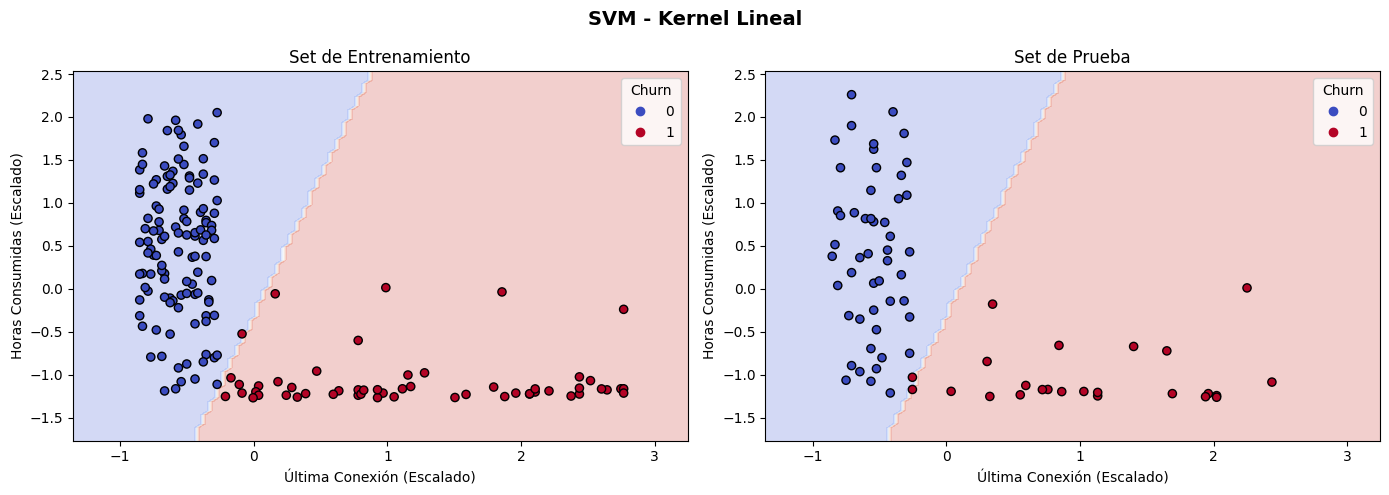

Exactitud del Kernel Lineal (Espacio 2D): 0.9865


In [72]:
print("Entrenando SVM con frontera lineal...")

svm_linear = SVC(kernel='linear', C=1.0, random_state=42)
svm_linear.fit(X_train_2d, y_train_s)

plot_decision_regions(svm_linear, X_train_2d, y_train_s, X_test_2d, y_test_s, title="SVM - Kernel Lineal")

acc_lin_2d = accuracy_score(y_test_s, svm_linear.predict(X_test_2d))
print(f"Exactitud del Kernel Lineal (Espacio 2D): {acc_lin_2d:.4f}")

Entrenando SVM con frontera polinomial...


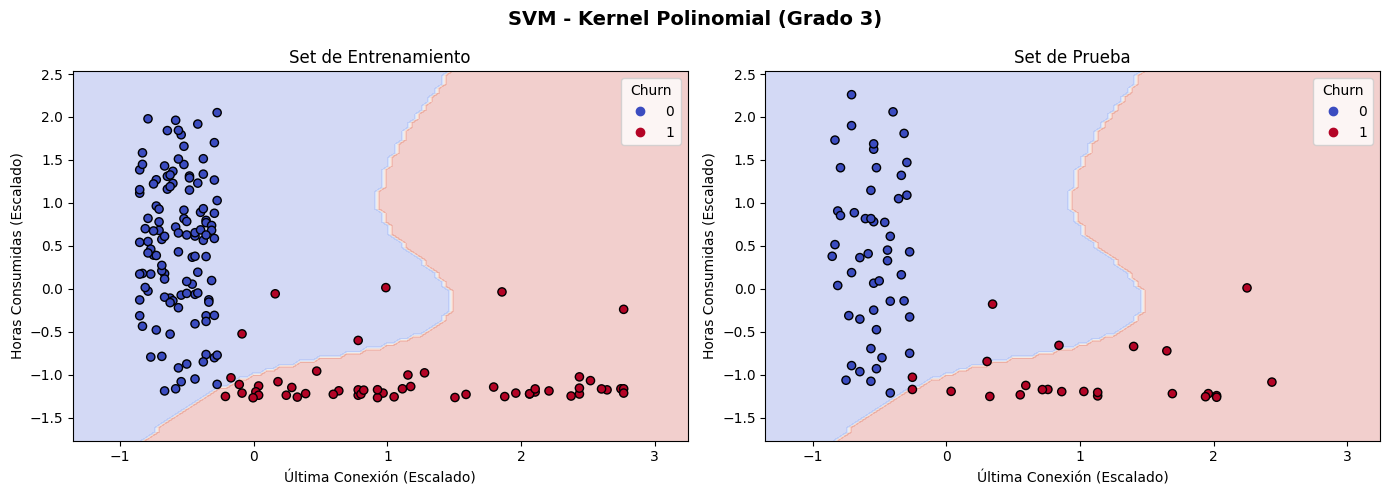

Exactitud del Kernel Polinomial (Espacio 2D): 0.9459


In [73]:
print("Entrenando SVM con frontera polinomial...")
svm_poly = SVC(kernel='poly', degree=3, C=1.0, random_state=42)
svm_poly.fit(X_train_2d, y_train_s)


plot_decision_regions(svm_poly, X_train_2d, y_train_s, X_test_2d, y_test_s, title="SVM - Kernel Polinomial (Grado 3)")

acc_poly_2d = accuracy_score(y_test_s, svm_poly.predict(X_test_2d))
print(f"Exactitud del Kernel Polinomial (Espacio 2D): {acc_poly_2d:.4f}")

Entrenando SVM con frontera RBF (Radial Basis Function)...


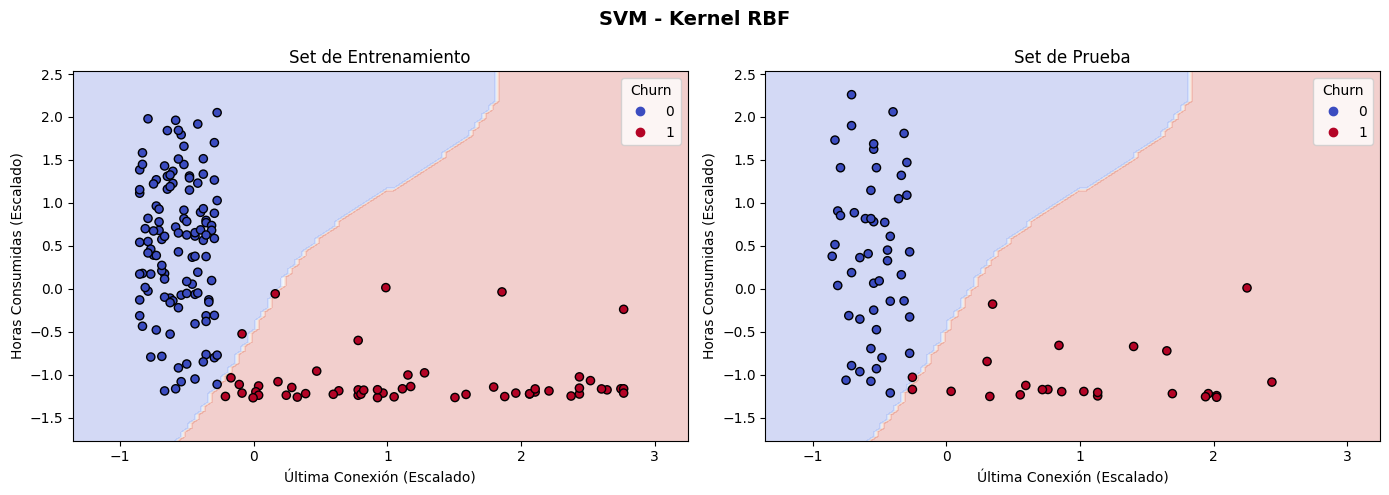

Exactitud del Kernel RBF (Espacio 2D): 0.9865


In [74]:
print("Entrenando SVM con frontera RBF (Radial Basis Function)...")

svm_rbf = SVC(kernel='rbf', gamma='scale', C=1.0, random_state=42)
svm_rbf.fit(X_train_2d, y_train_s)

plot_decision_regions(svm_rbf, X_train_2d, y_train_s, X_test_2d, y_test_s, title="SVM - Kernel RBF")

acc_rbf_2d = accuracy_score(y_test_s, svm_rbf.predict(X_test_2d))
print(f"Exactitud del Kernel RBF (Espacio 2D): {acc_rbf_2d:.4f}")

In [76]:
print("=== EVALUACIÓN DEL MODELO COMPLETO CON TODAS LAS VARIABLES ===")

svm_final = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svm_final.fit(X_train_scaled, y_train_s)

# Predicciones finales
y_pred_svm = svm_final.predict(X_test_scaled)
y_prob_svm = svm_final.predict_proba(X_test_scaled)[:, 1]

print("\n[Reporte de Clasificación Detallado para SVM]:")
print(classification_report(y_test_s, y_pred_svm))

acc_svm_final = accuracy_score(y_test_s, y_pred_svm)
auc_svm_final = roc_auc_score(y_test_s, y_prob_svm)

print(f"Accuracy Final (Modelo Completo): {acc_svm_final:.4f}")
print(f"ROC-AUC Final (Modelo Completo): {auc_svm_final:.4f}")

nueva_tecnica = pd.DataFrame({'Modelo': ['Support Vector Machine'], 'Accuracy': [acc_svm_final], 'ROC-AUC': [auc_svm_final]})
comparacion_final = pd.concat([comparacion_final, nueva_tecnica], ignore_index=True)
print(comparacion_final)

=== EVALUACIÓN DEL MODELO COMPLETO CON TODAS LAS VARIABLES ===

[Reporte de Clasificación Detallado para SVM]:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           1       1.00      0.96      0.98        24

    accuracy                           0.99        74
   macro avg       0.99      0.98      0.98        74
weighted avg       0.99      0.99      0.99        74

Accuracy Final (Modelo Completo): 0.9865
ROC-AUC Final (Modelo Completo): 1.0000
                   Modelo  Accuracy   ROC-AUC
0     Regresión Logística  0.972973  0.998333
1           Random Forest  0.972973  0.998333
2  Support Vector Machine  0.986486  1.000000


###https://github.com/SillonComodo/Chrun-streaming-.git